# Motor-imagery EEG: artifact correction and CSP–LDA decoding

**Purpose.** In this notebook I compare preprocessing methods for blink artifact correction on the BCI Competition IV 2a dataset.

**Prerequisites:** This notebook requires access to the BCI Competition IV 2a dataset, which can be downloaded from https://www.bbci.de/competition/iv/#download. The dataset is expected to be in `/BCICIV_2a_gdf`.

**Workflow:** load GDF recordings → correct blink artifacts (EOG regression, ICA, ICLabel) → filter and epoch motor-imagery trials → CSP–LDA cross-validation → held-out evaluation.

## 1. Load the BCI Competition IV 2a dataset

In [1]:
import mne
import os
mne.viz.set_browser_backend('matplotlib')
from pathlib import Path
import numpy as np


datadir = 'BCICIV_2a_gdf'

os.makedirs('raw', exist_ok=True)

# Load the training data for all subjects
raws = []
for subject in range(1, 10):
    if not os.path.exists(Path("raw", f"A0{subject}_raw.fif")):
        raw = mne.io.read_raw_gdf(Path(datadir, f"A0{subject}T.gdf"), preload=True)
        raws.append(raw)
        raw.save(Path("raw", f"A0{subject}_raw.fif"), overwrite=True)
    else:
        raw = mne.io.read_raw_fif(Path("raw", f"A0{subject}_raw.fif"), preload=True)
        raws.append(raw)

Using matplotlib as 2D backend.
Extracting GDF parameters from BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
Writing /Users/brainsimulation/Desktop/bciciv2a/raw/A01_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/raw/A01_raw.fif
[done]
Extracting GDF parameters from BCICIV_2a_gdf/A02T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Writing /Users/brainsimulation/Desktop/bciciv2a/raw/A02_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/raw/A02_raw.fif
[done]
Extracting GDF parameters from BCICIV_2a_gdf/A03T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 660529  =      0.000 ...  2642.116 secs...


...

Writing /Users/brainsimulation/Desktop/bciciv2a/raw/A07_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/raw/A07_raw.fif
[done]
Extracting GDF parameters from BCICIV_2a_gdf/A08T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Writing /Users/brainsimulation/Desktop/bciciv2a/raw/A08_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/raw/A08_raw.fif
[done]
Extracting GDF parameters from BCICIV_2a_gdf/A09T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 673327  =      0.000 ...  2693.308 secs...


/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Writing /Users/brainsimulation/Desktop/bciciv2a/raw/A09_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/raw/A09_raw.fif
[done]


## 2. Blink-artifact correction

We explicitly type EOG channels so MNE can use them as artifact channels, and apply Common Average Referencing to the signal.

In [2]:
import matplotlib.pyplot as plt

# Mark the EOG channels
raws = [
    raw.set_channel_types({
        'EOG-left': 'eog',
        'EOG-central': 'eog',
        'EOG-right': 'eog'
    })
    for raw in raws
]

# Apply CAR
ref_raws = [
    mne.set_eeg_reference(raw, 'average', projection=False)[0]
    for raw in raws
]

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


### 2.1 EOG regression

EOG regression estimates how much of the EEG signal is due to blink-related artefacts, and then removes that part of the signal. We fit EOG regression to the data before filtering, but after referencing. The weights fitted during the training here are saved for each participant, so that they can be later reused for artifact removal on the evaluation dataset.

No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Writing /Users/brainsimulation/Desktop/bciciv2a/preproc/A01_regr_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/preproc/A01_regr_raw.fif
[done]
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Writing /Users/brainsimulation/Desktop/bciciv2a/preproc/A02_regr_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/preproc/A02_regr_raw.fif
[done]
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
Writing /Users/brainsimulation/Desktop/bciciv2a/preproc/A03_regr_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/preproc/A03_regr_raw.fif
[done]
No projector specified for this dataset. Pl

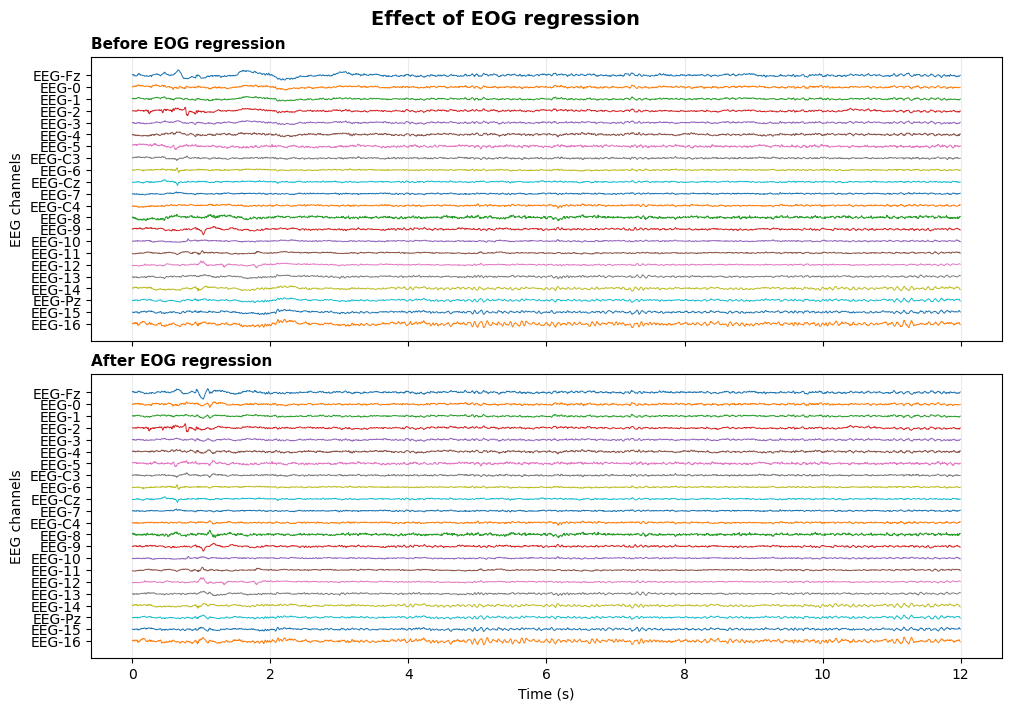

In [3]:
from mne.preprocessing import EOGRegression
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np

os.makedirs("preproc", exist_ok=True)
os.makedirs("eog_regression", exist_ok=True)

regr_raws = []
for i, raw in enumerate(ref_raws):
    weights = EOGRegression(picks="eeg", picks_artifact="eog").fit(raw)

    with open(Path("eog_regression", f"A0{i+1}_regr_weights.pkl"), "wb") as f:
        pickle.dump(weights, f)

    regr_raw = weights.apply(raw, copy=True)
    regr_raws.append(regr_raw)
    regr_raw.save(Path("preproc", f"A0{i+1}_regr_raw.fif"), overwrite=True)


# Plot a comparison of the EEG signals before and after EOG regression
raw_before = ref_raws[0]
raw_after = regr_raws[0]

duration = 12
start = 0

eeg_picks = mne.pick_types(raw_before.info, eeg=True, eog=False)
times = raw_before.times
mask = (times >= start) & (times < start + duration)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, raw, title in zip(
    axes,
    [raw_before, raw_after],
    ["Before EOG regression", "After EOG regression"]
):
    data = raw.get_data(picks=eeg_picks)[:, mask] * 1e6  # Convert to µV
    t = times[mask]

    # Vertically offset channels for readability
    offsets = np.arange(len(eeg_picks))[::-1] * 100
    ax.plot(t, data.T + offsets, linewidth=0.7)

    ch_names = [raw.ch_names[p] for p in eeg_picks]
    ax.set_yticks(offsets)
    ax.set_yticklabels(ch_names)
    ax.set_title(title, loc="left", fontsize=11, weight="bold")
    ax.set_ylabel("EEG channels")
    ax.grid(axis="x", alpha=0.25)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    "Effect of EOG regression",
    fontsize=14,
    weight="bold"
)

plt.show()

### 2.2 ICA and ICLabel

Winkler et al. (2015) (https://pubmed.ncbi.nlm.nih.gov/26737196/) found that 1–2 Hz filtering benefited ICA artifact correction, improving subsequent classification accuracy. We follow their methodology, applying a 2 Hz high-pass filter to remove slow drifts from the signal before artifact correction.

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 2 Hz

FIR filter parameters
--

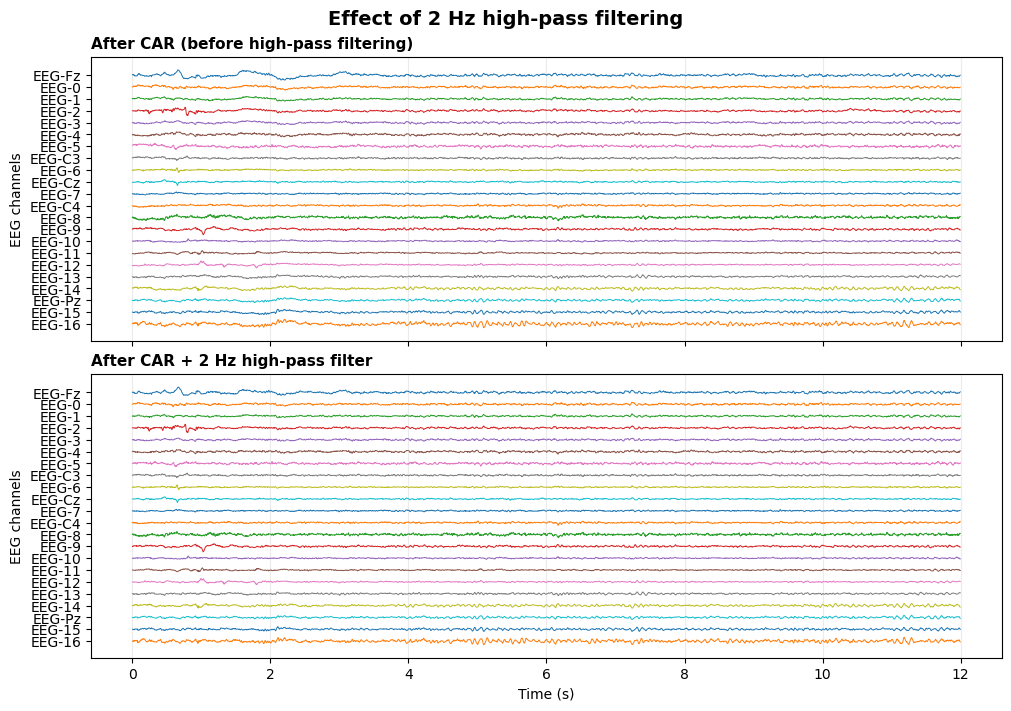

In [ ]:
filt_raws = [
    raw.copy().filter(l_freq=2, h_freq=None)
    for raw in ref_raws
]

# Plot the a comparison plot of the EEG signals before and after filtering
raw_before = ref_raws[0]
raw_after = filt_raws[0]
duration = 12
start = 0

eeg_picks = mne.pick_types(raw_before.info, eeg=True, eog=False)
times = raw_before.times
mask = (times >= start) & (times < start + duration)

fig, axes = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, sharey=True,
    constrained_layout=True
)

for ax, raw, title in zip(
    axes,
    [raw_before, raw_after],
    ["After CAR (before high-pass filtering)", "After CAR + 2 Hz high-pass filter"]
):
    data = raw.get_data(picks=eeg_picks)[:, mask] * 1e6  # Convert to µV
    t = times[mask]

    # Offset channels vertically for readability
    offsets = np.arange(len(eeg_picks))[::-1] * 100
    ax.plot(t, data.T + offsets, linewidth=0.7)

    ch_names = [raw.ch_names[p] for p in eeg_picks]
    ax.set_yticks(offsets)
    ax.set_yticklabels(ch_names)
    ax.set_title(title, loc="left", fontsize=11, weight="bold")
    ax.grid(axis="x", alpha=0.25)
    ax.set_ylabel("EEG channels")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Effect of 2 Hz high-pass filtering", fontsize=14, weight="bold")
plt.show()

We use ICA to identify independent components of the signal. To make this preprocessing pipeline scalable to larger datasets, I use automatic methods to identify the artifact components. Two methods are compared:
 
 - The MNE `find_bads_eog()` function that selects components correlated with EOG channels.
 - The ICLabel classifier trained to automatically identify component types.


Subject 0 processing
Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 18.7s.
Simple ICA
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lowe

/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_65327/3190864430.py:50: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")
/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_65327/3190864430.py:50: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  ic_labels = label_components(raw, ica, method="iclabel")


Writing ICA solution to /Users/brainsimulation/Desktop/bciciv2a/ica/A01_iclabel.fif...
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 3 ICA components
    Projecting back using 22 PCA components
Writing /Users/brainsimulation/Desktop/bciciv2a/preproc/A01_iclabel_raw.fif


/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_65327/3190864430.py:61: RuntimeWarning: This filename (ica/A01_iclabel.fif) does not conform to MNE naming conventions. All ICA files should end with -ica.fif, -ica.fif.gz, _ica.fif or _ica.fif.gz
  ica.save(Path("ica", f"A0{i+1}_iclabel.fif"), overwrite=True)


Closing /Users/brainsimulation/Desktop/bciciv2a/preproc/A01_iclabel_raw.fif
[done]

Subject 1 processing
Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 11.7s.
Simple ICA
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpa

...

Writing /Users/brainsimulation/Desktop/bciciv2a/preproc/A08_iclabel_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/preproc/A08_iclabel_raw.fif
[done]

Subject 8 processing
Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 15.6s.
Simple ICA
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
-----------------

/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_65327/3190864430.py:50: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw, ica, method="iclabel")
/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_65327/3190864430.py:50: RuntimeWarning: The provided ICA instance was fitted with a 'fastica' algorithm. ICLabel was designed with extended infomax ICA decompositions. To use the extended infomax algorithm, use the 'mne.preprocessing.ICA' instance with the arguments 'ICA(method='infomax', fit_params=dict(extended=True))' (scikit-learn) or 'ICA(method='picard', fit_params=dict(ortho=False, extended=True))' (python-picard).
  ic_labels = label_components(raw, ica, method="iclabel")


Writing ICA solution to /Users/brainsimulation/Desktop/bciciv2a/ica/A09_iclabel.fif...
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 5 ICA components
    Projecting back using 22 PCA components


/var/folders/mn/q624n0lj15s26j52tyhh602h0000gn/T/ipykernel_65327/3190864430.py:61: RuntimeWarning: This filename (ica/A09_iclabel.fif) does not conform to MNE naming conventions. All ICA files should end with -ica.fif, -ica.fif.gz, _ica.fif or _ica.fif.gz
  ica.save(Path("ica", f"A0{i+1}_iclabel.fif"), overwrite=True)


Writing /Users/brainsimulation/Desktop/bciciv2a/preproc/A09_iclabel_raw.fif
Closing /Users/brainsimulation/Desktop/bciciv2a/preproc/A09_iclabel_raw.fif
[done]


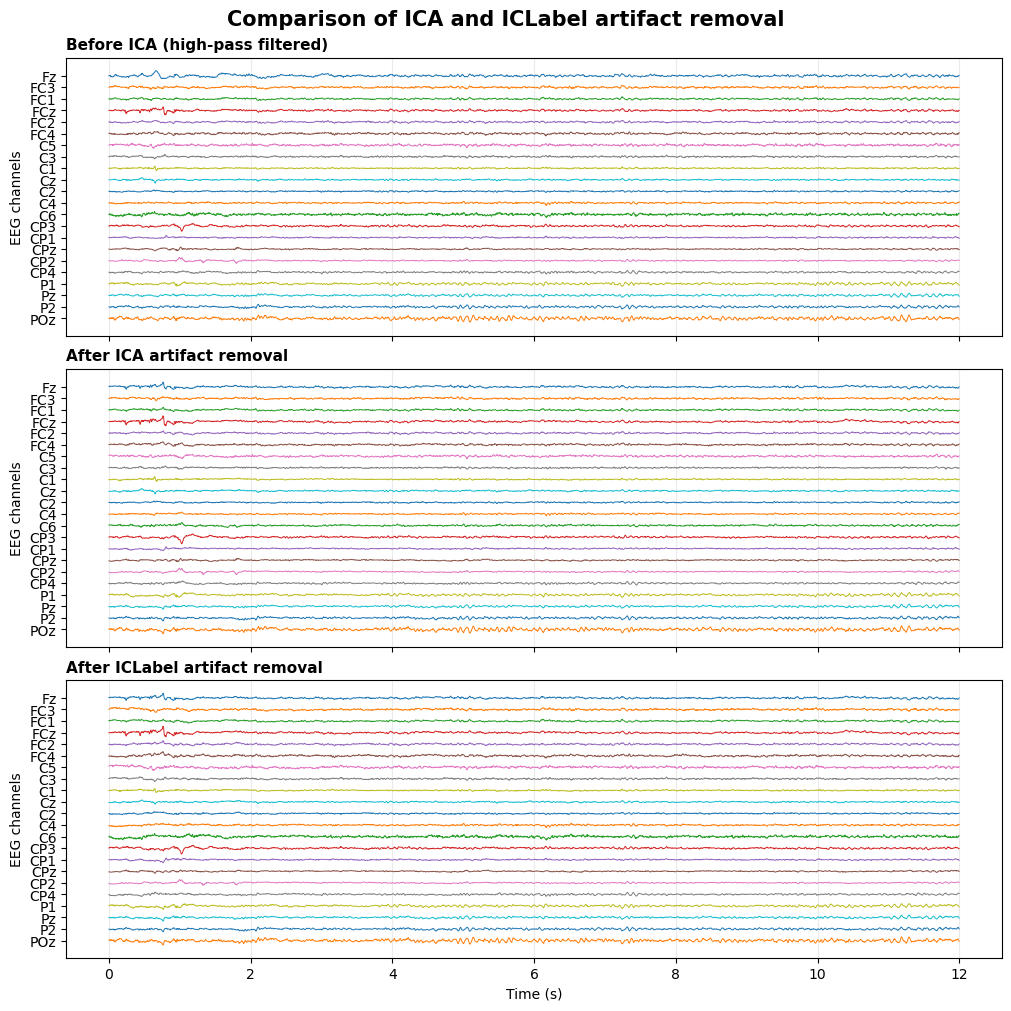

In [5]:
from mne.preprocessing import ICA
from mne_icalabel import label_components

ica_raws = []
iclabel_raws = []

for i, raw in enumerate(filt_raws):

    print(f"\nSubject {i} processing")

    # Rename channels to match the BCI IV 2a dataset channel names
    ch_names_2a = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
                'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    eeg_ch_current = [ch for ch in raw.ch_names if ch not in ['EOG-left', 'EOG-central', 'EOG-right']]
    rename_dict = dict(zip(eeg_ch_current, ch_names_2a))

    if raw.ch_names != ch_names_2a:
        raw.rename_channels(rename_dict)

    # The BCI IV 2a dataset uses the standard 10-20 system for electrode placement, so we set the montage accordingly
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))

    # Fit ICA to the high-pass filtered raw data
    ica = ICA(n_components=15, random_state=42, max_iter='auto')
    ica.fit(raw)

    print("Simple ICA")

    # Automatically select components correlated with EOG channels
    eog_indices, eog_scores = ica.find_bads_eog(raw)
    ica.exclude = eog_indices

    # Save the fitted ICA (unmixing matrix + find_bads_eog exclusions) so it can be reused
    # on session 2 without refitting
    os.makedirs("ica", exist_ok=True)
    ica.save(Path("ica", f"A0{i+1}_ica.fif"), overwrite=True)

    # Apply to the unfiltered raw
    ica_raw = ref_raws[i].copy()
    if ica_raw.ch_names != ch_names_2a:
        ica_raw.rename_channels(rename_dict)
    ica.apply(ica_raw)

    ica_raws.append(ica_raw)
    ica_raw.save(Path("preproc", f"A0{i+1}_ica_raw.fif"), overwrite=True)

    print("ICLabel")

    # Use ICLabel to pick components
    ic_labels = label_components(raw, ica, method="iclabel")
    labels = ic_labels["labels"]
    # Exclude components that are not classified as "brain" or "other" == artifact components
    exclude_idx = [
        idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
    ]
    ica.exclude = exclude_idx

    # Save the fitted ICA (unmixing matrix + ICLabel exclusions) so it can be reused
    # on session 2 without refitting
    os.makedirs("ica", exist_ok=True)
    ica.save(Path("ica", f"A0{i+1}_iclabel.fif"), overwrite=True)
    
    # Apply ICA to the unfiltered raw data
    iclabel_raw = ref_raws[i].copy()
    if iclabel_raw.ch_names != ch_names_2a:
        iclabel_raw.rename_channels(rename_dict)
    ica.apply(iclabel_raw)

    iclabel_raws.append(iclabel_raw)
    iclabel_raw.save(Path("preproc", f"A0{i+1}_iclabel_raw.fif"), overwrite=True)

import matplotlib.pyplot as plt
import numpy as np
import mne

# Plot a comparison of the EEG signals before and after ICA and ICLabel artifact removal
raw_before = filt_raws[0]
raw_ica = ica_raws[0]
raw_iclabel = iclabel_raws[0]

duration = 12
start = 0

eeg_picks = mne.pick_types(raw_before.info, eeg=True, eog=False)
times = raw_before.times
mask = (times >= start) & (times < start + duration)

raws_to_plot = [raw_before, raw_ica, raw_iclabel]
titles = [
    "Before ICA (high-pass filtered)",
    "After ICA artifact removal",
    "After ICLabel artifact removal",
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Use consistent vertical offsets across all panels
offsets = np.arange(len(eeg_picks))[::-1] * 100
ch_names = [raw_before.ch_names[p] for p in eeg_picks]

for ax, raw, title in zip(axes, raws_to_plot, titles):
    data = raw.get_data(picks=eeg_picks)[:, mask] * 1e6  # Convert to µV
    t = times[mask]

    ax.plot(t, data.T + offsets, linewidth=0.7)
    ax.set_yticks(offsets)
    ax.set_yticklabels(ch_names)
    ax.set_title(title, loc="left", fontsize=11, weight="bold")
    ax.set_ylabel("EEG channels")
    ax.grid(axis="x", alpha=0.25)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    "Comparison of ICA and ICLabel artifact removal",
    fontsize=15,
    weight="bold"
)

plt.show()

## 3. Filter and epoch

Epoching initially failed because of duplicate event labels. We first inspect which labels are colliding:

In [6]:
import numpy as np
import mne

events, event_id = mne.events_from_annotations(raws[0])

# event code -> event name
event_names = {
    276: "Idling EEG (eyes open)",
    277: "Idling EEG (eyes closed)",
    768: "Start of a trial",
    769: "Cue onset left (class 1)",
    770: "Cue onset right (class 2)",
    771: "Cue onset foot (class 3)",
    772: "Cue onset tongue (class 4)",
    783: "Cue unknown",
    1023: "Rejected trial",
    1072: "Eye movements",
    32766: "Start of a new run",
}

# Reverse MNE's annotation mapping: event integer -> annotation description
id_to_annotation = {v: k for k, v in event_id.items()}

samples = events[:, 0]
unique_samples, counts = np.unique(samples, return_counts=True)
dupes = unique_samples[counts > 1]

print(f"Duplicated sample indices: {dupes}")

for sample in dupes:
    print(f"\nSample {sample}:")
    for event in events[events[:, 0] == sample]:
        code = event[2]
        annotation = id_to_annotation.get(code, "Unknown annotation")
        name = event_names[int(event_names.get(code, annotation))]
        print(f"  Code {code}: {name}")

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Duplicated sample indices: [     0  29683  49955 133886 182202 196584 204593 226571 281151 287541
 289459 301428 476880 523138 553652 603615 648515 670550]

Sample 0:
  Code 5: Start of a new run
  Code 3: Idling EEG (eyes open)

Sample 29683:
  Code 5: Start of a new run
  Code 4: Idling EEG (eyes closed)

Sample 49955:
  Code 5: Start of a new run
  Code 2: Eye movements

Sample 133886:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 182202:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 196584:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 204593:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 226571:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 281151:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 287541:
  Code 6: Start of a trial
  Code 1: Rejected trial

Sample 289459:
  Code 6: Start of a trial

All collisions are between either 'Idling EEG'/'Eye movements' and 'Start of a new run' or between 'Start of a trial' and 'Rejected trial'. It is therefore warranted to drop repeated events during epoching.

### Epoching

We use the 8–30 Hz band-pass filter to target the mu/beta range that contains most discriminatory signal in motor-imagery. Epochs span 0–4 s with no baseline correction. Duplicate events are dropped by MNE.

In [7]:
import mne
from pathlib import Path
from mne import pick_types

tmin=0
tmax=4

# For both regression and ICA cleaning
all_epochs = {}

# We create epochs for each subject and each method (regression, ICA, ICLabel)
for method in ["regr", "ica", "iclabel"]:
    all_epochs[method] = []

    for subject in range(1, 10):
        # Load the preprocessed raw data for the current subject and method
        raw = mne.io.read_raw_fif(Path("preproc", f"A0{subject}_{method}_raw.fif"), preload=True)
        # Bandpass filter tu mu/beta band
        filt_raw = raw.filter(l_freq=8, h_freq=30)

        # Epoch
        events, event_id = mne.events_from_annotations(filt_raw)
        picks = pick_types(filt_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
        epochs = mne.Epochs(filt_raw, events, event_id=event_id, picks=picks, tmin=tmin, tmax=tmax, baseline=None, preload=True, event_repeated='drop')

        all_epochs[method].append(epochs)

# We also create epochs for the raw data (without any artifact removal) for comparison
all_epochs["raw"] = []

for subject in range(1, 10):
        raw = mne.io.read_raw_fif(Path("raw", f"A0{subject}_raw.fif"), preload=True)
        filt_raw = raw.filter(l_freq=8, h_freq=30)

        # Epoch
        events, event_id = mne.events_from_annotations(filt_raw)
        picks = pick_types(filt_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
        epochs = mne.Epochs(filt_raw, events, event_id=event_id, picks=picks, tmin=tmin, tmax=tmax, baseline=None, preload=True, event_repeated='drop')

        all_epochs["raw"].append(epochs)

Opening raw data file preproc/A01_regr_raw.fif...
Isotrak not found
    Range : 0 ... 672527 =      0.000 ...  2690.108 secs
Ready.
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Multiple event values for single event times found. Keeping the first occurrence and dropping all others.
Not setting metadata
585 matching event

## 4. CSP + LDA evaluation

To evalute the different preprocessing methods, we use the standard CSP + LDA pipeline that is often used as a solid baseline model in BCI research.

For each subject, we use cross-validation on the data from session 1 to evaluate the performance of different preprocessing methods.
The data from session 2 is used as a held-out test set to evaluate the performance of the best processing+classification pipeline on new data. This way we prevent test data leakage into the preprocessing method selection process.

### 4.1 Within session

#### 4.1.1 Uncorrected baseline

In [8]:
from sklearn.preprocessing import LabelEncoder
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import cohen_kappa_score, make_scorer
from sklearn.pipeline import Pipeline
import numpy as np

inses_accs_raw = []
inses_kappas_raw = []

for subject in range(9):
    epochs = all_epochs["raw"][subject]

    # Pick only the epochs leading up to the 4 class labels ()
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
    lda = LinearDiscriminantAnalysis()
    clf = Pipeline([('CSP', csp), ('LDA', lda)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = cross_validate(clf, X, y, cv=cv, scoring={'accuracy': 'balanced_accuracy', 'kappa': make_scorer(cohen_kappa_score)}, n_jobs=-1)

    print(f"Subject {subject+1} accuracy: {np.mean(results['test_accuracy']):.3f} ± {np.std(results['test_accuracy']):.3f}")
    print(f"Subject {subject+1} kappa: {np.mean(results['test_kappa']):.3f} ± {np.std(results['test_kappa']):.3f}")
        
    inses_accs_raw.append(np.mean(results['test_accuracy']))
    inses_kappas_raw.append(np.mean(results['test_kappa']))

print(f"Average balanced accuracy: {np.mean(inses_accs_raw):.3f}")
print(f"Average kappa: {np.mean(inses_kappas_raw):.3f}")

Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 6e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Using tolerance 6e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Using tolerance 6e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Using tolerance 6e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Using tolerance 6e-05 (2.2e-16 eps * 25 dim * 1.1e+10  max singular value)
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
    Estimated rank (data): 25
    data: rank 25 computed from 25 data channels with 0 projectors
    Estimated ran

#### 4.1.2 EOG regression

In [9]:
from sklearn.preprocessing import LabelEncoder
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import cohen_kappa_score, make_scorer
from sklearn.pipeline import Pipeline
import numpy as np

inses_accs_regr = []
inses_kappas_regr = []


for subject in range(9):
    epochs = all_epochs["regr"][subject]

    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
    lda = LinearDiscriminantAnalysis()
    clf = Pipeline([('CSP', csp), ('LDA', lda)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = cross_validate(clf, X, y, cv=cv, scoring={'accuracy': 'balanced_accuracy', 'kappa': make_scorer(cohen_kappa_score)}, n_jobs=-1)

    print(f"Subject {subject+1} accuracy: {np.mean(results['test_accuracy']):.3f} ± {np.std(results['test_accuracy']):.3f}")
    print(f"Subject {subject+1} kappa: {np.mean(results['test_kappa']):.3f} ± {np.std(results['test_kappa']):.3f}")
        
    inses_accs_regr.append(np.mean(results['test_accuracy']))
    inses_kappas_regr.append(np.mean(results['test_kappa']))

print(f"Average EOG regression balanced accuracy: {np.mean(inses_accs_regr):.3f}")
print(f"Average EOG regression kappa: {np.mean(inses_kappas_regr):.3f}")

Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.2e+09  max singular value)
    Using tolerance 2e-05 (2.2e

#### 4.1.3 ICA

In [10]:
inses_accs_ica = []
inses_kappas_ica = []

for subject in range(9):
    epochs = all_epochs["ica"][subject]

    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
    lda = LinearDiscriminantAnalysis()
    clf = Pipeline([('CSP', csp), ('LDA', lda)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = cross_validate(clf, X, y, cv=cv, scoring={'accuracy': 'balanced_accuracy', 'kappa': make_scorer(cohen_kappa_score)}, n_jobs=-1)
    
    print(f"Subject {subject+1} accuracy: {np.mean(results['test_accuracy']):.3f} ± {np.std(results['test_accuracy']):.3f}")
    print(f"Subject {subject+1} kappa: {np.mean(results['test_kappa']):.3f} ± {np.std(results['test_kappa']):.3f}")
        
    inses_accs_ica.append(np.mean(results['test_accuracy']))
    inses_kappas_ica.append(np.mean(results['test_kappa']))

print(f"Average ICA balanced accuracy: {np.mean(inses_accs_ica):.3f}")
print(f"Average ICA kappa: {np.mean(inses_kappas_ica):.3f}")

Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Reducing data rank from 22 -> 2

#### 4.1.4 ICLabel

In [11]:
inses_accs_iclabel = []
inses_kappas_iclabel = []

for subject in range(9):
    epochs = all_epochs["iclabel"][subject]

    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
    lda = LinearDiscriminantAnalysis()
    clf = Pipeline([('CSP', csp), ('LDA', lda)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = cross_validate(clf, X, y, cv=cv, scoring={'accuracy': 'balanced_accuracy', 'kappa': make_scorer(cohen_kappa_score)}, n_jobs=-1)
    
    print(f"Subject {subject+1} accuracy: {np.mean(results['test_accuracy']):.3f} ± {np.std(results['test_accuracy']):.3f}")
    print(f"Subject {subject+1} kappa: {np.mean(results['test_kappa']):.3f} ± {np.std(results['test_kappa']):.3f}")
        
    inses_accs_iclabel.append(np.mean(results['test_accuracy']))
    inses_kappas_iclabel.append(np.mean(results['test_kappa']))

print(f"Average ICLabel balanced accuracy: {np.mean(inses_accs_iclabel):.3f}")
print(f"Average ICLabel kappa: {np.mean(inses_kappas_iclabel):.3f}")

Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4e+09  max singular value)
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Using tolerance 2e-05 (2.2e-16 eps * 22 dim * 4.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Reducing data ran

#### Save results

In [12]:
import os

os.makedirs('results', exist_ok=True)

np.savetxt(Path('results', 'csp_inses_accs_regr.csv'), inses_accs_regr, delimiter=',')
np.savetxt(Path('results', 'csp_inses_kappas_regr.csv'), inses_kappas_regr, delimiter=',')
np.savetxt(Path('results', 'csp_inses_accs_ica.csv'), inses_accs_ica, delimiter=',')
np.savetxt(Path('results', 'csp_inses_kappas_ica.csv'), inses_kappas_ica, delimiter=',')
np.savetxt(Path('results', 'csp_inses_accs_iclabel.csv'), inses_accs_iclabel, delimiter=',')
np.savetxt(Path('results', 'csp_inses_kappas_iclabel.csv'), inses_kappas_iclabel, delimiter=',')

#### Comparison plot

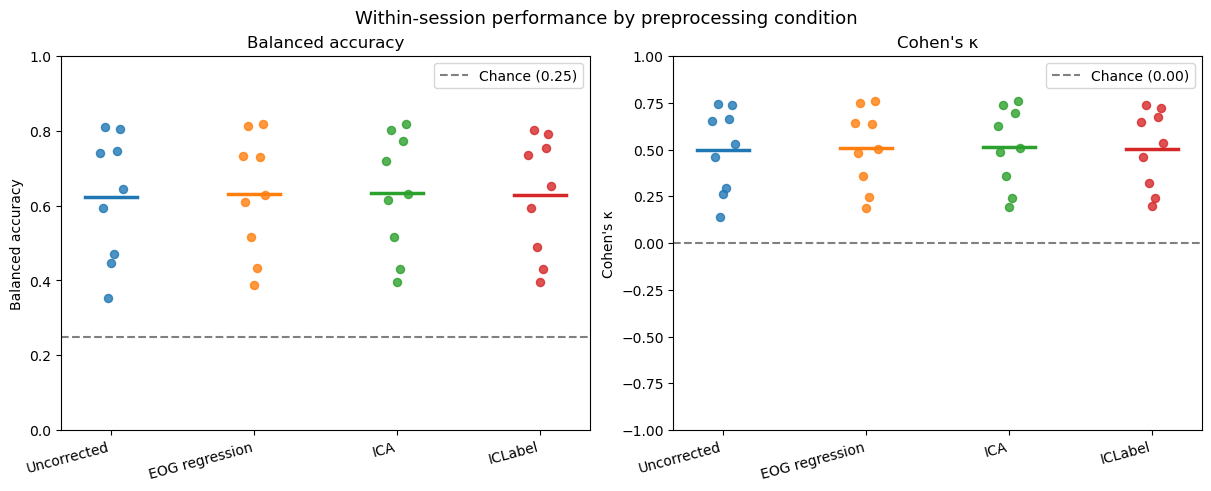

In [13]:
import matplotlib.pyplot as plt
import numpy as np

methods = [
    ("Uncorrected", inses_accs_raw, inses_kappas_raw),
    ("EOG regression", inses_accs_regr, inses_kappas_regr),
    ("ICA", inses_accs_ica, inses_kappas_ica),
    ("ICLabel", inses_accs_iclabel, inses_kappas_iclabel),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

for ax, metric_idx, title, limits, chance in [
    (axes[0], 1, "Balanced accuracy", (0, 1), 0.25),
    (axes[1], 2, "Cohen's κ", (-1, 1), 0.0),
]:
    for xpos, (name, accs, kappas) in enumerate(methods):
        values = np.asarray(accs if metric_idx == 1 else kappas, dtype=float)
        jitter = np.linspace(-0.08, 0.08, len(values))

        ax.scatter(xpos + jitter, values, s=34, alpha=0.8, zorder=3)
        ax.plot(
            [xpos - 0.18, xpos + 0.18],
            [values.mean()] * 2,
            linewidth=2.5,
            zorder=4,
        )

    ax.axhline(
        chance,
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=f"Chance ({chance:.2f})",
    )
    ax.set_xticks(range(len(methods)), [m[0] for m in methods],
                  rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.set_ylim(*limits)
    ax.set_title(title)
    ax.legend()

fig.suptitle("Within-session performance by preprocessing condition", fontsize=13)
plt.show()


Based on the classification performance on session 1 data, the best performing preprocessing method is ICA with identification of artifact components using correlation with the EOG channel signal. We will evaluate this method on the held-out session 2 dataset.

### 4.2 Held-out-session evaluation

In [14]:
from sklearn.metrics import cohen_kappa_score, balanced_accuracy_score
from scipy.io import loadmat
from mne.preprocessing import ICA, read_ica

CH_NAMES_2A = ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
               'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
EOG_CHS = ['EOG-left', 'EOG-central', 'EOG-right']

datadir = "BCICIV_2a_gdf"

best_method = "ica"

outses_accs = []
outses_kappas = []

# Retrain on whole training set for each subject and evaluate on session 2
for subject in range(9):
    epochs = all_epochs[best_method][subject]
    
    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    csp = CSP(n_components=6, reg='ledoit_wolf', log=True, norm_trace=False)
    lda = LinearDiscriminantAnalysis()
    clf = Pipeline([('CSP', csp), ('LDA', lda)])

    clf.fit(X, y)

    # Load test session
    raw = mne.io.read_raw_gdf(Path(datadir, f"A0{subject+1}E.gdf"), preload=True)

    # Test session preprocessing

    # Mark the EOG channels
    raw.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'})
    
    # Reference using CAR
    ref_raw = mne.set_eeg_reference(raw, 'average', projection=False)[0]

    # Apply ICA trained on session 1
    eeg_current = [ch for ch in raw.ch_names if ch not in EOG_CHS]
    raw.rename_channels(dict(zip(eeg_current, CH_NAMES_2A)))
    ica = read_ica(Path("ica", f"A0{subject+1}_ica.fif"))
    clean_raw = ica.apply(raw)

    # Bandpass filter to mu/beta band
    mubeta_raw = clean_raw.filter(l_freq=8, h_freq=30)

    # Epoch
    events, event_id = mne.events_from_annotations(mubeta_raw)
    picks = pick_types(mubeta_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
    epochs = mne.Epochs(mubeta_raw, events, event_id=event_id, picks=picks, tmin=tmin, tmax=tmax, baseline=None, preload=True, event_repeated='drop')
    trial_epochs = epochs[['768']] # Start of a trial event code

    # Get data and labels
    X = trial_epochs.get_data()

    # Get true labels
    y_true = LabelEncoder().fit_transform(loadmat(Path(datadir, 'true_labels', f'A0{subject+1}E.mat'))['classlabel'].flatten())
    
    y_pred = clf.predict(X)

    outses_accs.append(balanced_accuracy_score(y_true, y_pred))
    outses_kappas.append(cohen_kappa_score(y_true, y_pred))

    print(f"Subject {subject+1} - kappa = {cohen_kappa_score(y_true, y_pred):.3f}, accuracy = {balanced_accuracy_score(y_true, y_pred):.3f}")

print(f"Average kappa = {np.mean(outses_kappas):.3f}, average accuracy = {np.mean(outses_accs):.3f}")

Computing rank from data with rank=None
    Using tolerance 2.2e-05 (2.2e-16 eps * 22 dim * 4.6e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Extracting GDF parameters from BCICIV_2a_gdf/A01E.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 686999  =      0.000 ...  2747.996 secs...


/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reading /Users/brainsimulation/Desktop/bciciv2a/ica/A01_ica.fif ...
Now restoring ICA solution ...
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 22 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', 

/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reading /Users/brainsimulation/Desktop/bciciv2a/ica/A02_ica.fif ...
Now restoring ICA solution ...
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 22 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '

...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reading /Users/brainsimulation/Desktop/bciciv2a/ica/A07_ica.fif ...
Now restoring ICA solution ...
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 22 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', 

/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reading /Users/brainsimulation/Desktop/bciciv2a/ica/A08_ica.fif ...
Now restoring ICA solution ...
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 22 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', 

/Users/brainsimulation/miniconda3/envs/eeg-torch/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Reading /Users/brainsimulation/Desktop/bciciv2a/ica/A09_ica.fif ...
Now restoring ICA solution ...
Ready.
Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 2 ICA components
    Projecting back using 22 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', 

#### Save results

In [15]:
import os

os.makedirs('results', exist_ok=True)

np.savetxt(Path('results', 'csp_outses_accs.csv'), outses_accs, delimiter=',')
np.savetxt(Path('results', 'csp_outses_kappas.csv'), outses_kappas, delimiter=',')

#### Comparison plot

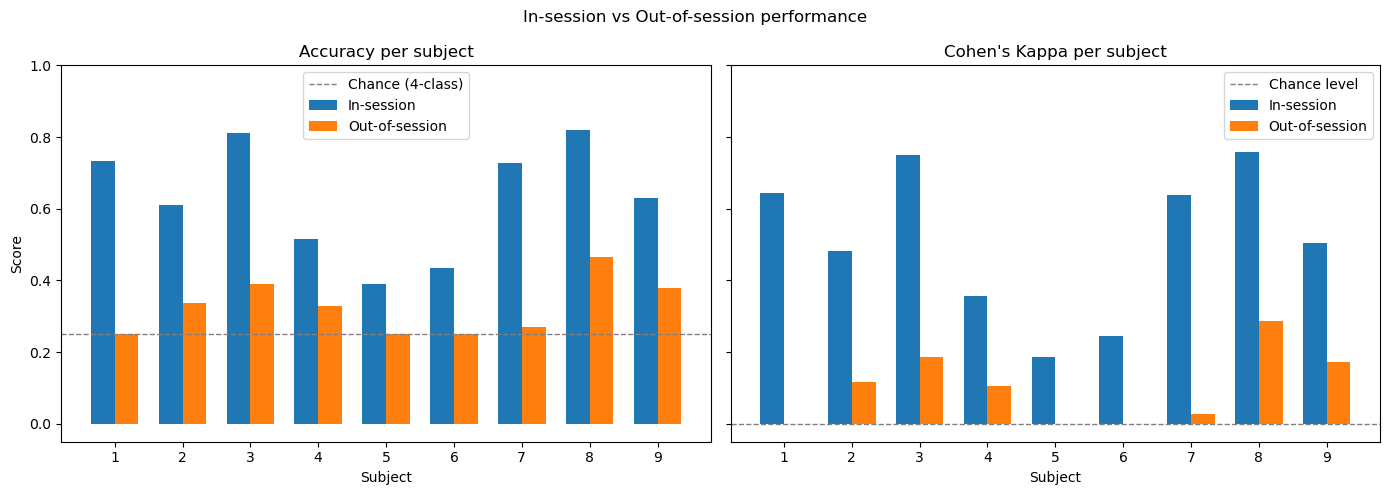

Average in-session accuracy: 0.630
Average out-of-session accuracy: 0.324
Average in-session Cohen's kappa: 0.507
Average out-of-session Cohen's kappa: 0.099


In [16]:
import matplotlib.pyplot as plt

inses_accs = inses_accs_regr
inses_kappas = inses_kappas_regr

n = len(outses_accs)
x = np.arange(n)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
# --- Accuracy subplot ---
ax = axes[0]
ax.bar(x - width/2, inses_accs, width, label="In-session")
ax.bar(x + width/2, outses_accs, width, label="Out-of-session")
ax.set_title("Accuracy per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.legend()
ax.set_ylim(0, 1)
 
# --- Kappa subplot ---
ax = axes[1]
ax.bar(x - width/2, inses_kappas, width, label="In-session")
ax.bar(x + width/2, outses_kappas, width, label="Out-of-session")
ax.set_title("Cohen's Kappa per subject")
ax.set_xlabel("Subject")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.legend()
ax.set_ylim(-0.05, 1)
 
fig.suptitle("In-session vs Out-of-session performance")
fig.tight_layout()
plt.show()

print(f"Average in-session accuracy: {np.mean(inses_accs):.3f}")
print(f"Average out-of-session accuracy: {np.mean(outses_accs):.3f}")
print(f"Average in-session Cohen's kappa: {np.mean(inses_kappas):.3f}")
print(f"Average out-of-session Cohen's kappa: {np.mean(outses_kappas):.3f}")

As expected, performance on out of session data was worse than within session. The learned patterns useful for classification in session 1 did not fully generalise to session 2. However, even out of session performance remained above chance level (average balanced accuracy across subjects was 0.40 for 4 conditions).